In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter

# ── Load data ──────────────────────────────────────────────────────────────────
DATA_PATH = "../data/processed/survey_v1.1.json"

with open(DATA_PATH) as f:
    data = json.load(f)

N = len(data)
print(f"Loaded {N} records, {len(data[0])} fields each.")

# ── Shared style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Colour palette (one per section)
C_MEAS  = "#4C72B0"   # blue  – measures
C_BUILD = "#55A868"   # green – building
C_SOCIO = "#C44E52"   # red   – sociodemographics
C_TRIG  = "#DD8452"   # orange – triggers & subsidies

def pct_of(values, total=None):
    """Return list of percentages."""
    t = total or sum(values)
    return [v / t * 100 for v in values]

def get_field(field, cast=str):
    """Return non-null values of a field, cast to type."""
    return [cast(r[field]) for r in data if r.get(field) is not None]

Loaded 1651 records, 143 fields each.


---
## 4 · Triggers & Subsidies

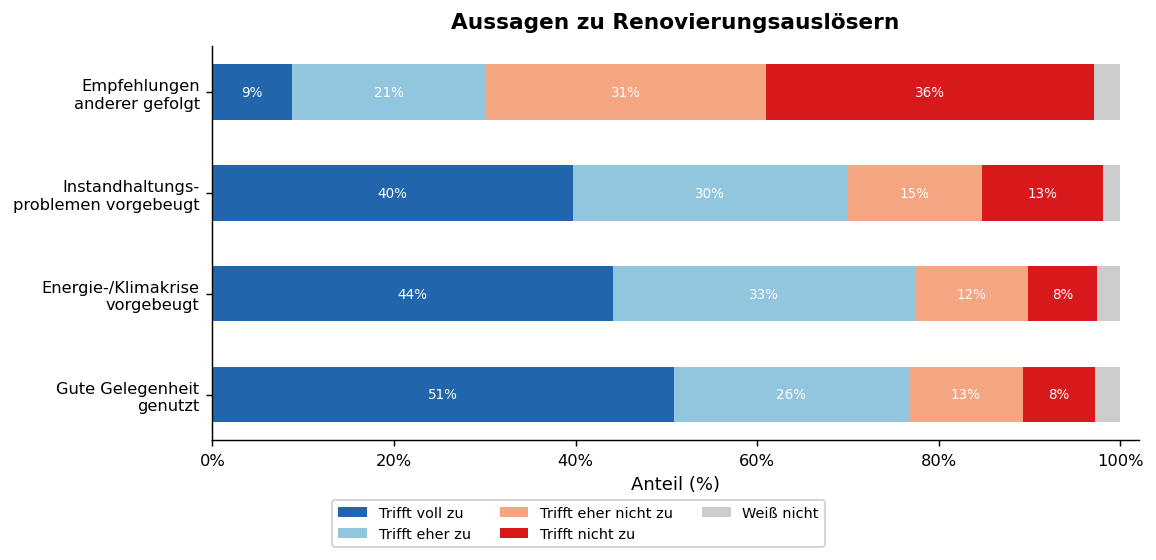

In [4]:
# ── 4a: Trigger statements — stacked Likert bar ───────────────────────────────
# Scale: 1=Fully agree, 2=Rather agree, 3=Rather disagree, 4=Fully disagree, 5=Don't know
trig_fields = ["TRIG_1", "TRIG_2", "TRIG_3", "TRIG_4"]
trig_labels = [
    "Gute Gelegenheit\ngenutzt",
    "Energie-/Klimakrise\nvorgebeugt",
    "Instandhaltungs-\nproblemen vorgebeugt",
    "Empfehlungen\nanderer gefolgt",
]
likert_labels  = ["Trifft voll zu", "Trifft eher zu", "Trifft eher nicht zu", "Trifft nicht zu", "Wei\u00df nicht"]
likert_colors  = ["#2166ac", "#92c5de", "#f4a582", "#d7191c", "#cccccc"]
likert_vals    = ["1", "2", "3", "4", "5"]

trig_data = {}
for field in trig_fields:
    vals  = get_field(field)
    total = len(vals)
    trig_data[field] = [vals.count(v) / total * 100 for v in likert_vals]

fig, ax = plt.subplots(figsize=(9, 4))
y_pos = np.arange(len(trig_fields))
left  = np.zeros(len(trig_fields))

for i, (lbl, color) in enumerate(zip(likert_labels, likert_colors)):
    widths = [trig_data[f][i] for f in trig_fields]
    bars   = ax.barh(y_pos, widths, left=left, color=color, height=0.55, label=lbl)
    for bar, w in zip(bars, widths):
        if w > 4:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{w:.0f}%", ha="center", va="center", fontsize=7.5, color="white")
    left += np.array(widths)

ax.set_yticks(y_pos)
ax.set_yticklabels(trig_labels, fontsize=9)
ax.set_xlabel("Anteil (%)")
ax.set_title("Aussagen zu Renovierungsausl\u00f6sern", pad=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 102)
fig.legend(loc="lower center", fontsize=8, ncol=3, bbox_to_anchor=(0.5, -0.08), framealpha=0.9)
plt.tight_layout()
plt.show()
